In [2]:
"""
Verificación integral de un cubo NetCDF ERA5 (EDA)

Este script:
1. Controla existencia de archivos (.nc / .zip)
2. Carga el dataset en modo lazy
3. Inspecciona:
   - dimensiones
   - variable principal
   - metadatos
   - forma del arreglo
4. Verifica la estructura vertical (niveles de presión)

Contexto físico:
---------------
La presión disminuye con la altura:
    ~1 hPa     → estratosfera alta
    ~500 hPa   → troposfera media
    ~1000 hPa  → superficie
"""

import xarray as xr
import os
import zipfile

# -------------------------------------------------------------------------
# Rutas
# -------------------------------------------------------------------------

path = "./data_heavy/"
ncname = "download5Dcolombia"
ncfile5d = os.path.join(path, ncname + ".nc")
zipfile_path = os.path.join(path, ncname + ".zip")


# -------------------------------------------------------------------------
# Control de existencia y descompresión
# -------------------------------------------------------------------------

if not os.path.exists(ncfile5d):

    if os.path.exists(zipfile_path):
        print(f"Archivo .nc no encontrado. Descomprimiendo {zipfile_path}")
        with zipfile.ZipFile(zipfile_path, 'r') as zip_ref:
            zip_ref.extractall(path)
    else:
        raise FileNotFoundError("No existe .nc ni .zip")

else:
    print(f"Usando archivo existente: {ncfile5d}")


# -------------------------------------------------------------------------
# Carga (lazy)
# -------------------------------------------------------------------------

# Carga lazy pero sin dask
ds = xr.open_dataset(ncfile5d)

# chunks="auto" activa Dask y divide el cubo en bloques manejables para la RAM
# Se requieren las librerías:
# xarray (instalada en el contenedor),
# netcdf4 (no instalada en el contenedor)
# y toolz (no instalada en el contenedor)
# ds = xr.open_dataset(ncfile5d, chunks="auto")

print("\n=== DATASET ===")
print(ds)


Usando archivo existente: ./data_heavy/download5Dcolombia.nc

=== DATASET ===
<xarray.Dataset> Size: 1GB
Dimensions:    (time: 480, number: 10, level: 37, latitude: 35, longitude: 25)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2020-01-01 ... 2020-02-29T21:00:00
  * number     (number) int32 40B 0 1 2 3 4 5 6 7 8 9
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * latitude   (latitude) float32 140B 12.5 12.0 11.5 11.0 ... -3.5 -4.0 -4.5
  * longitude  (longitude) float32 100B -79.1 -78.6 -78.1 ... -68.1 -67.6 -67.1
Data variables:
    t          (time, number, level, latitude, longitude) float64 1GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-30 17:55:04 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...


In [3]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 480, number: 10, level: 37, latitude: 35, longitude: 25)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2020-01-01 ... 2020-02-29T21:00:00
  * number     (number) int32 40B 0 1 2 3 4 5 6 7 8 9
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * latitude   (latitude) float32 140B 12.5 12.0 11.5 11.0 ... -3.5 -4.0 -4.5
  * longitude  (longitude) float32 100B -79.1 -78.6 -78.1 ... -68.1 -67.6 -67.1
Data variables:
    t          (time, number, level, latitude, longitude) float64 1GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-30 17:55:04 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [4]:
# -------------------------------------------------------------------------
# Dimensiones
# -------------------------------------------------------------------------

print("\n=== DIMENSIONES ===")
print(ds.dims)




=== DIMENSIONES ===
FrozenMappingWarningOnValuesAccess({'time': 480, 'number': 10, 'level': 37, 'latitude': 35, 'longitude': 25})


In [5]:
# -------------------------------------------------------------------------
# Variable principal
# -------------------------------------------------------------------------

print("\n=== VARIABLES ===")
print(list(ds.data_vars))



=== VARIABLES ===
['t']


In [6]:
# -------------------------------------------------------------------------
# Metadatos
# -------------------------------------------------------------------------

print("\n=== METADATOS ===")
print(ds.attrs)



=== METADATOS ===
{'Conventions': 'CF-1.6', 'history': '2020-09-30 17:55:04 GMT by grib_to_netcdf-2.16.0: /opt/ecmwf/eccodes/bin/grib_to_netcdf -S param -o /cache/data1/adaptor.mars.internal-1601485963.200975-3104-28-04adcc76-77fc-4223-96e1-62f83cb65870.nc /cache/tmp/04adcc76-77fc-4223-96e1-62f83cb65870-adaptor.mars.internal-1601485963.2020729-3104-9-tmp.grib'}


In [7]:
# -------------------------------------------------------------------------
# Forma del arreglo
# -------------------------------------------------------------------------

print("\n=== SHAPE ===")
print(ds["t"].shape)


=== SHAPE ===
(480, 10, 37, 35, 25)


In [9]:

# -------------------------------------------------------------------------
# Niveles de presión
# -------------------------------------------------------------------------

z_levels = ds.level.values
z_levels

array([   1,    2,    3,    5,    7,   10,   20,   30,   50,   70,  100,
        125,  150,  175,  200,  225,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  775,  800,  825,  850,  875,  900,
        925,  950,  975, 1000], dtype=int32)

In [10]:
print("\nPrimeros niveles (Alta atmósfera):")
print(z_levels[:2])

print("\nÚltimos niveles (Superficie):")
print(z_levels[-2:])


Primeros niveles (Alta atmósfera):
[1 2]

Últimos niveles (Superficie):
[ 975 1000]


<xarray.Dataset> Size: 14kB
Dimensions:    (level: 2, latitude: 35, longitude: 25)
Coordinates:
  * level      (level) int32 8B 1 2
  * latitude   (latitude) float32 140B 12.5 12.0 11.5 11.0 ... -3.5 -4.0 -4.5
  * longitude  (longitude) float32 100B -79.1 -78.6 -78.1 ... -68.1 -67.6 -67.1
    number     int32 4B 0
    time       datetime64[ns] 8B 2020-01-01
Data variables:
    t          (level, latitude, longitude) float64 14kB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-30 17:55:04 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...
<xarray.Dataset> Size: 1MB
Dimensions:    (time: 480, number: 10, level: 37, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2020-01-01 ... 2020-02-29T21:00:00
  * number     (number) int32 40B 0 1 2 3 4 5 6 7 8 9
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * latitude   (latitude) float32 4B 4.5
  * longitude  (longitude) float32 4B -74.1
Data variables:
    t          (ti

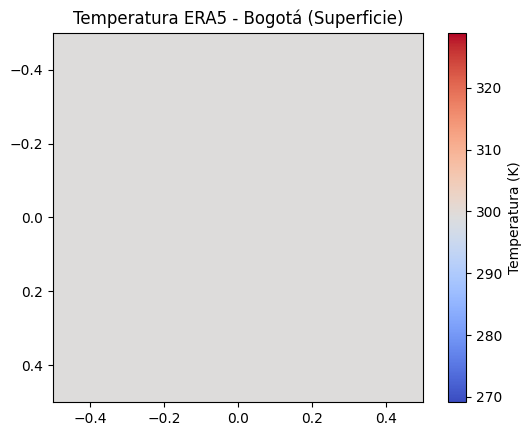

In [11]:
import matplotlib.pyplot as plt

# ============================================================
# Selección avanzada en cubo 5D (ERA5) con xarray
# - Selección por dimensiones (level, number, time)
# - Selección espacial (bounding box Bogotá)
# - Extracción de variable
# - Reducción a slice 2D + Visualización
# ============================================================

# -------------------------------------------------------------------------
# Selección 1: Subconjunto por dimensiones (label-based)
# -------------------------------------------------------------------------
# Selecciona:
# - miembro de ensamble 0
# - primeros dos niveles de presión
# - primer instante temporal
sel_dim = ds.sel(
    number=0,
    level=ds.level[:2],
    time=ds.time[0]
)

print(sel_dim)


# -------------------------------------------------------------------------
# Selección 2: Recorte espacial (Bogotá - WGS84)
# -------------------------------------------------------------------------
# Nota:
# - longitude = eje X
# - latitude  = eje Y
# - slice respeta orden de coordenadas

sel_bogota = ds.sel(
    longitude=slice(-74.25, -73.90),
    latitude=slice(4.85, 4.45)
)

print(sel_bogota)


# -------------------------------------------------------------------------
# Extracción de variable
# -------------------------------------------------------------------------
# 't' corresponde a temperatura (K)
t_bogota = sel_bogota["t"]

print(t_bogota)

# -------------------------------------------------------------------------
# Slice 2D (reducción dimensional)
# -------------------------------------------------------------------------
# Selecciona:
# - nivel más bajo (aprox. superficie)
# - ensamble 0
# - tiempo 0

capa_2d = t_bogota.isel(
    level=-1,
    number=0,
    time=0
)

print(capa_2d)

# Visualización de la matriz de datos
# El objeto se materializa (RAM) al usar .values
print(capa_2d.values)

# Verificación de las dimensiones restantes
print(capa_2d.dims)

# Verificación de los valores de las coordenadas
print(capa_2d.coords)

# Extracción de los valores de latitud o longitud asociados
eje_x = capa_2d.longitude.values
eje_y = capa_2d.latitude.values
print(eje_x)
print(eje_y)

# Verificación y extracción robusta
for dim in capa_2d.dims:
    print(f"Valores en la dimensión {dim}: {capa_2d[dim].values}")

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------



if capa_2d.size > 1:
    # Imprimir como mapa: requiere mínimo matriz de 2 x 2
    # El objeto se materializa (RAM) al usar .plot()
    capa_2d.plot(cmap="coolwarm")
else:
    print("⚠️ Solo hay un pixel, no se puede hacer plot espacial")
    # Esto ya no es un mapa, es un escalar
    plt.imshow(capa_2d.values.reshape(1,1), cmap="coolwarm")
    plt.colorbar(label="Temperatura (K)")

plt.title("Temperatura ERA5 - Bogotá (Superficie)")
plt.show()